# Lesson 01.5 — One pixel to one kernel

Apply small image filters and compare the visible results.

## Setup

Loads the Grace Hopper sample photo, finds the repository root, and creates
`results/lesson-01-5/`.

In [16]:
%matplotlib inline
from pathlib import Path
import subprocess

import cv2
from matplotlib import cbook
import matplotlib.pyplot as plt
import numpy as np


def find_repository_root(start):
    current = Path(start).resolve()
    for candidate in (current, *current.parents):
        if (candidate / ".git").exists():
            return candidate
    raise RuntimeError(
        "No Git repository root was found. The notebook must run inside "
        "the assigned repository."
    )


def plot_image(axis, image, title, display="gray"):
    image_array = np.asarray(image)
    if display == "rgb":
        axis.imshow(image_array)
    elif display == "signed":
        scale = max(
            float(np.percentile(np.abs(image_array), 99)),
            1.0,
        )
        axis.imshow(
            image_array,
            cmap="coolwarm",
            vmin=-scale,
            vmax=scale,
        )
    elif display == "change":
        upper = max(float(np.percentile(image_array, 99)), 1.0)
        axis.imshow(image_array, cmap="magma", vmin=0, vmax=upper)
    else:
        axis.imshow(image_array, cmap="gray", vmin=0, vmax=255)
    axis.set_title(title)
    axis.axis("off")


def save_figure(figure, filename):
    output_path = RESULTS_DIR / filename
    figure.tight_layout()
    figure.savefig(
        output_path,
        dpi=110,
        bbox_inches="tight",
        pil_kwargs={"optimize": True, "compress_level": 9},
    )
    plt.show()
    print("Saved:", output_path)
    return output_path


REPO_ROOT = find_repository_root(Path.cwd())
RESULTS_DIR = REPO_ROOT / "results" / "lesson-01-5"
if REPO_ROOT not in RESULTS_DIR.parents:
    raise RuntimeError("Results directory is outside the repository")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

BRANCH = subprocess.run(
    ["git", "branch", "--show-current"],
    cwd=REPO_ROOT,
    check=True,
    capture_output=True,
    text=True,
).stdout.strip()

PHOTO_PATH = Path(
    cbook.get_sample_data("grace_hopper.jpg", asfileobj=False)
)
photo_bgr = cv2.imread(str(PHOTO_PATH), cv2.IMREAD_COLOR)
if photo_bgr is None:
    raise RuntimeError(f"OpenCV could not read the sample photo: {PHOTO_PATH}")
photo_bgr = cv2.resize(
    photo_bgr,
    (256, 300),
    interpolation=cv2.INTER_AREA,
)
photo_rgb = cv2.cvtColor(photo_bgr, cv2.COLOR_BGR2RGB)
photo_gray = cv2.cvtColor(photo_bgr, cv2.COLOR_BGR2GRAY).astype(
    np.float32
)

print("Repository root:", REPO_ROOT)
print("Git branch:", BRANCH or "(detached)")
print("Results directory:", RESULTS_DIR)
print("Sample photo:", PHOTO_PATH.name)
print("NumPy:", np.__version__)
print("OpenCV:", cv2.__version__)

Repository root: C:\Users\Adity\Downloads\Official-Website-portfolio
Git branch: main
Results directory: C:\Users\Adity\Downloads\Official-Website-portfolio\results\lesson-01-5
Sample photo: grace_hopper.jpg
NumPy: 2.5.1
OpenCV: 5.0.0


## One pixel, one result

A kernel is a small array of coefficients. One output pixel is calculated from
one image neighborhood.

1. Place the kernel center on the input pixel.
2. Multiply each kernel value by the matching image value.
3. Add the products.
4. Store the sum at the center location.

Correlation applies the kernel as written. Convolution flips the kernel in both
axes first. A border rule supplies values outside the image.

The cell below works one 3×3 patch through those steps, then box-blurs the
whole photo with the same kernel.

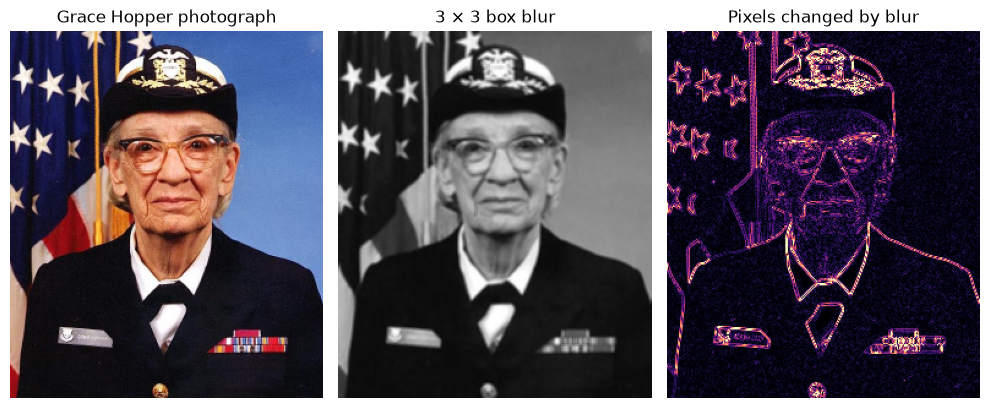

Saved: C:\Users\Adity\Downloads\Official-Website-portfolio\results\lesson-01-5\01-box-blur.png
Nine products:
 [[0.22222222 0.44444445 0.6666667 ]
 [0.8888889  1.1111112  1.3333334 ]
 [1.5555556  1.7777778  2.        ]]
Average: 10.0


In [17]:
worked_patch = np.array(
    [[2, 4, 6], [8, 10, 12], [14, 16, 18]], dtype=np.float32
)
box_kernel = np.ones((3, 3), dtype=np.float32) / 9.0
worked_products = worked_patch * box_kernel
worked_sum = float(worked_products.sum())

assert np.isclose(worked_sum, 10.0)
assert np.array_equal(
    box_kernel, np.flip(box_kernel, axis=(0, 1))
)

box_blurred = cv2.filter2D(
    photo_gray,
    cv2.CV_32F,
    box_kernel,
    borderType=cv2.BORDER_REFLECT_101,
)
blur_change = np.abs(box_blurred - photo_gray)

figure, axes = plt.subplots(1, 3, figsize=(10, 4))
plot_image(axes[0], photo_rgb, "Grace Hopper photograph", display="rgb")
plot_image(axes[1], box_blurred, "3 × 3 box blur")
plot_image(axes[2], blur_change, "Pixels changed by blur", display="change")
save_figure(figure, "01-box-blur.png")

print("Nine products:\n", worked_products)
print("Average:", worked_sum)

## Checkpoint 1 — correlation by hand

Run the multiply-and-add loop on a single 3×3 patch, then apply the same kernel
across the whole photo with `filter2D`. The kernel is deliberately asymmetric —
that matters in the next checkpoint.

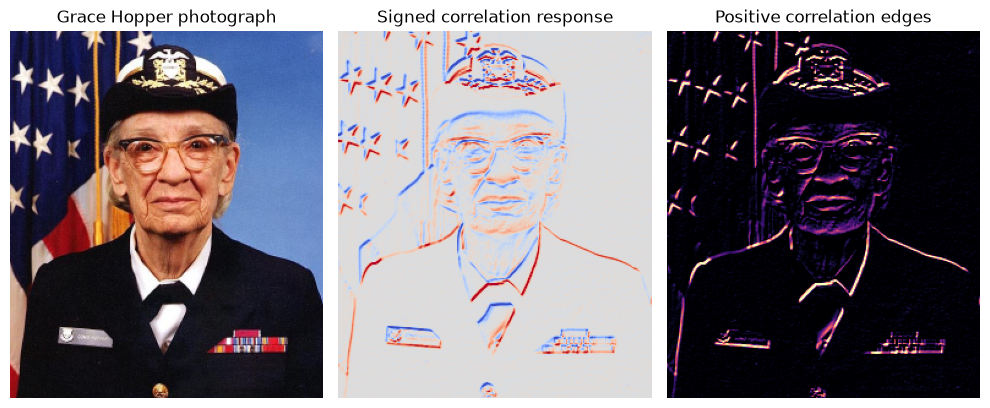

Saved: C:\Users\Adity\Downloads\Official-Website-portfolio\results\lesson-01-5\02-correlation-edges.png
Correlation products:
 [[  1.   4.   0.]
 [  0.   0.   0.]
 [  0.  -8. -18.]]
Correlation: -21.0


In [19]:
def correlate_at(patch, kernel):
    patch_array = np.asarray(patch, dtype=np.float32)
    kernel_array = np.asarray(kernel, dtype=np.float32)
    if patch_array.ndim != 2 or kernel_array.ndim != 2:
        raise ValueError("patch and kernel must be two-dimensional")
    if patch_array.shape != kernel_array.shape:
        raise ValueError("patch and kernel shapes must match")
    if any(size % 2 == 0 for size in patch_array.shape):
        raise ValueError("patch and kernel dimensions must be odd")

    total = 0.0
    for row in range(patch_array.shape[0]):
        for column in range(patch_array.shape[1]):
            total += float(
                patch_array[row, column] * kernel_array[row, column]
            )
    return total


input_patch = np.array(
    [[1, 2, 3], [4, 5, 6], [7, 8, 9]], dtype=np.float32
)
asymmetric_kernel = np.array(
    [[1, 2, 0], [0, 0, 0], [0, -1, -2]], dtype=np.float32
)
correlation_products = input_patch * asymmetric_kernel
correlation_result = correlate_at(input_patch, asymmetric_kernel)
correlation_image = cv2.filter2D(
    photo_gray,
    cv2.CV_32F,
    asymmetric_kernel,
    borderType=cv2.BORDER_REFLECT_101,
)

figure, axes = plt.subplots(1, 3, figsize=(10, 4))
plot_image(axes[0], photo_rgb, "Grace Hopper photograph", display="rgb")
plot_image(
    axes[1],
    correlation_image,
    "Signed correlation response",
    display="signed",
)
plot_image(
    axes[2],
    np.maximum(correlation_image, 0),
    "Positive correlation edges",
    display="change",
)
save_figure(figure, "02-correlation-edges.png")

print("Correlation products:\n", correlation_products)
print("Correlation:", correlation_result)

## Checkpoint 2 — convolution needs a flip

Flips the kernel in both axes, then does the same multiply-and-add. On this
patch the flip swaps the sign: correlation gives `-21`, convolution gives `21`.
The checks cell after it confirms both values against NumPy and OpenCV's
`filter2D`.

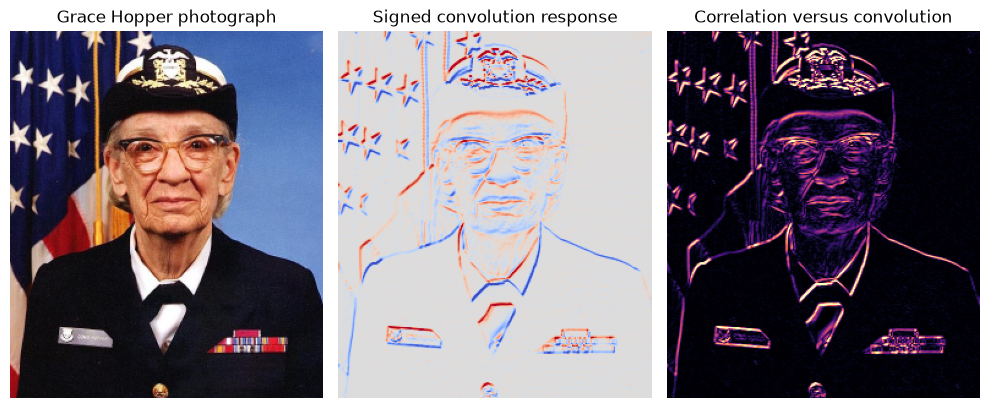

Saved: C:\Users\Adity\Downloads\Official-Website-portfolio\results\lesson-01-5\03-convolution-edges.png
Flipped kernel:
 [[-2. -1.  0.]
 [ 0.  0.  0.]
 [ 0.  2.  1.]]
Convolution products:
 [[-2. -2.  0.]
 [ 0.  0.  0.]
 [ 0. 16.  9.]]
Convolution: 21.0


In [20]:
def convolve_at(patch, kernel):
    flipped = np.flip(np.asarray(kernel), axis=(0, 1))
    return correlate_at(patch, flipped)


flipped_kernel = np.flip(asymmetric_kernel, axis=(0, 1))
convolution_products = input_patch * flipped_kernel
convolution_result = convolve_at(input_patch, asymmetric_kernel)
convolution_image = cv2.filter2D(
    photo_gray,
    cv2.CV_32F,
    flipped_kernel,
    borderType=cv2.BORDER_REFLECT_101,
)
direction_difference = np.abs(
    correlation_image - convolution_image
)

figure, axes = plt.subplots(1, 3, figsize=(10, 4))
plot_image(axes[0], photo_rgb, "Grace Hopper photograph", display="rgb")
plot_image(
    axes[1],
    convolution_image,
    "Signed convolution response",
    display="signed",
)
plot_image(
    axes[2],
    direction_difference,
    "Correlation versus convolution",
    display="change",
)
save_figure(figure, "03-convolution-edges.png")

print("Flipped kernel:\n", flipped_kernel)
print("Convolution products:\n", convolution_products)
print("Convolution:", convolution_result)

In [21]:
reference_correlation = float(np.multiply(
    input_patch, asymmetric_kernel
).sum())
reference_convolution = float(np.multiply(
    input_patch, flipped_kernel
).sum())
opencv_center = float(cv2.filter2D(
    input_patch,
    cv2.CV_32F,
    asymmetric_kernel,
    borderType=cv2.BORDER_CONSTANT,
)[1, 1])

assert np.isclose(correlation_result, -21.0)
assert np.isclose(convolution_result, 21.0)
assert np.isclose(correlation_result, reference_correlation)
assert np.isclose(convolution_result, reference_convolution)
assert np.isclose(correlation_result, opencv_center)
assert not np.isclose(correlation_result, convolution_result)
KERNEL_CHECKS_PASSED = True

print("PASS — correlation:", correlation_result)
print("PASS — convolution:", convolution_result)
print("PASS — OpenCV center:", opencv_center)

PASS — correlation: -21.0
PASS — convolution: 21.0
PASS — OpenCV center: -21.0


## A symmetric kernel hides a missing flip

Repeats both operations with a symmetric kernel. Flipping it changes nothing,
so correlation and convolution agree — which is why a symmetric kernel can
never catch a forgotten flip.

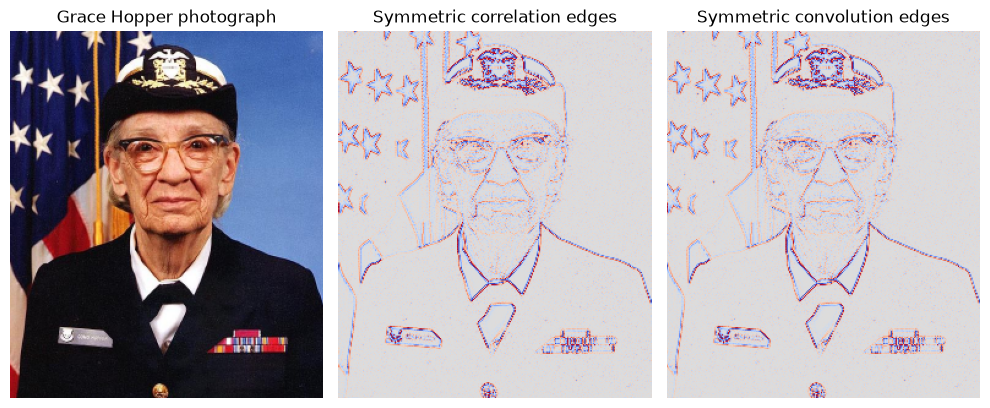

Saved: C:\Users\Adity\Downloads\Official-Website-portfolio\results\lesson-01-5\04-symmetric-edges.png
Symmetric correlation: 0.0
Symmetric convolution: 0.0
Difference: 0.0


In [22]:
symmetric_kernel = np.array(
    [[0, 1, 0], [1, -4, 1], [0, 1, 0]], dtype=np.float32
)
symmetric_flipped = np.flip(symmetric_kernel, axis=(0, 1))
symmetric_correlation = correlate_at(input_patch, symmetric_kernel)
symmetric_convolution = convolve_at(input_patch, symmetric_kernel)
symmetric_difference = abs(
    symmetric_correlation - symmetric_convolution
)
symmetric_correlation_image = cv2.filter2D(
    photo_gray,
    cv2.CV_32F,
    symmetric_kernel,
    borderType=cv2.BORDER_REFLECT_101,
)
symmetric_convolution_image = cv2.filter2D(
    photo_gray,
    cv2.CV_32F,
    symmetric_flipped,
    borderType=cv2.BORDER_REFLECT_101,
)

assert np.array_equal(symmetric_kernel, symmetric_flipped)
assert np.isclose(symmetric_difference, 0.0)
assert np.array_equal(
    symmetric_correlation_image,
    symmetric_convolution_image,
)
SYMMETRY_CHECK_PASSED = True

figure, axes = plt.subplots(1, 3, figsize=(10, 4))
plot_image(axes[0], photo_rgb, "Grace Hopper photograph", display="rgb")
plot_image(
    axes[1],
    symmetric_correlation_image,
    "Symmetric correlation edges",
    display="signed",
)
plot_image(
    axes[2],
    symmetric_convolution_image,
    "Symmetric convolution edges",
    display="signed",
)
save_figure(figure, "04-symmetric-edges.png")

print("Symmetric correlation:", symmetric_correlation)
print("Symmetric convolution:", symmetric_convolution)
print("Difference:", symmetric_difference)

## Checkpoint 3 — border rules

Pads the top-left corner two ways — zeros versus reflection — and runs the same
kernel on each. The padding invents different neighbors, so the same corner
pixel gets a different answer. The checks cell after it verifies both patches,
then shows the two border rules on a heavy blur of the photo.

In [23]:
def corner_patch(image, mode):
    image_array = np.asarray(image, dtype=np.float32)
    if image_array.ndim != 2:
        raise ValueError("image must be two-dimensional")
    if min(image_array.shape) < 2:
        raise ValueError("image dimensions must be at least two")
    if mode not in {"constant", "reflect"}:
        raise ValueError("mode must be constant or reflect")

    padded = np.pad(image_array, 1, mode=mode)
    return padded[:3, :3].astype(np.float32)


border_image = np.arange(1, 17, dtype=np.float32).reshape(4, 4)
constant_patch = corner_patch(border_image, "constant")
reflect_patch = corner_patch(border_image, "reflect")

print("Constant corner patch:\n", constant_patch)
print("Reflected corner patch:\n", reflect_patch)

Constant corner patch:
 [[0. 0. 0.]
 [0. 1. 2.]
 [0. 5. 6.]]
Reflected corner patch:
 [[6. 5. 6.]
 [2. 1. 2.]
 [6. 5. 6.]]


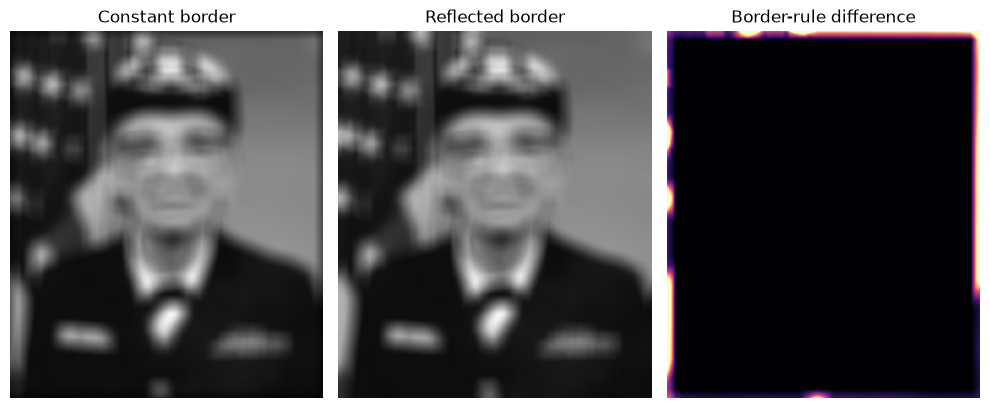

Saved: C:\Users\Adity\Downloads\Official-Website-portfolio\results\lesson-01-5\05-border-effects.png
PASS — constant corner response: -17.0
PASS — reflected corner response: -1.0


In [24]:
expected_constant_patch = np.array(
    [[0, 0, 0], [0, 1, 2], [0, 5, 6]], dtype=np.float32
)
expected_reflect_patch = np.array(
    [[6, 5, 6], [2, 1, 2], [6, 5, 6]], dtype=np.float32
)

assert np.array_equal(constant_patch, expected_constant_patch)
assert np.array_equal(reflect_patch, expected_reflect_patch)

constant_response = correlate_at(constant_patch, asymmetric_kernel)
reflect_response = correlate_at(reflect_patch, asymmetric_kernel)
assert np.isclose(constant_response, -17.0)
assert np.isclose(reflect_response, -1.0)
assert not np.isclose(constant_response, reflect_response)
CHECKS_PASSED = KERNEL_CHECKS_PASSED and SYMMETRY_CHECK_PASSED

border_kernel = np.ones((15, 15), dtype=np.float32) / 225.0
constant_border_image = cv2.filter2D(
    photo_gray,
    cv2.CV_32F,
    border_kernel,
    borderType=cv2.BORDER_CONSTANT,
)
reflected_border_image = cv2.filter2D(
    photo_gray,
    cv2.CV_32F,
    border_kernel,
    borderType=cv2.BORDER_REFLECT_101,
)
border_difference_image = np.abs(
    constant_border_image - reflected_border_image
)

figure, axes = plt.subplots(1, 3, figsize=(10, 4))
plot_image(axes[0], constant_border_image, "Constant border")
plot_image(axes[1], reflected_border_image, "Reflected border")
plot_image(
    axes[2],
    border_difference_image,
    "Border-rule difference",
    display="change",
)
save_figure(figure, "05-border-effects.png")

print("PASS — constant corner response:", constant_response)
print("PASS — reflected corner response:", reflect_response)

## Checkpoint 4 — emboss in two directions

Embosses the photo with a kernel as written and with its flip. The flip is the
kernel's exact negative, so the relief lighting reverses direction on the same
photo.

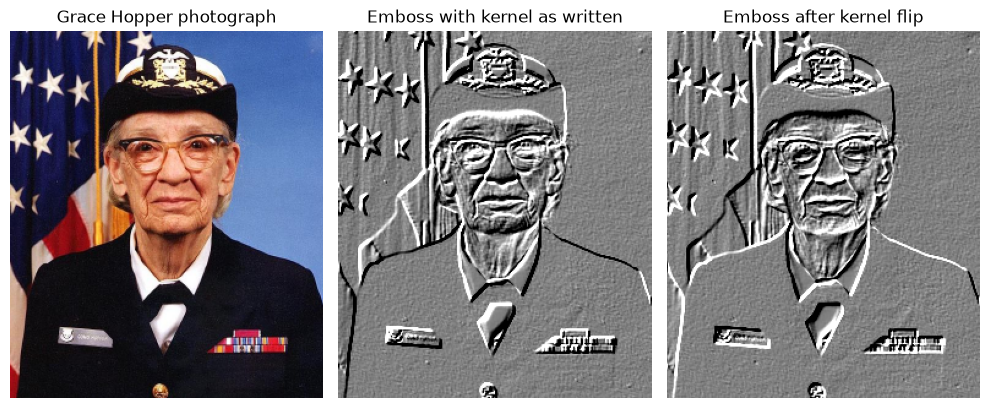

Saved: C:\Users\Adity\Downloads\Official-Website-portfolio\results\lesson-01-5\06-emboss-directions.png


WindowsPath('C:/Users/Adity/Downloads/Official-Website-portfolio/results/lesson-01-5/06-emboss-directions.png')

In [25]:
emboss_kernel = np.array(
    [[-2, -1, 0], [-1, 0, 1], [0, 1, 2]], dtype=np.float32
)
emboss_flipped = np.flip(emboss_kernel, axis=(0, 1))
emboss_correlation_response = cv2.filter2D(
    photo_gray,
    cv2.CV_32F,
    emboss_kernel,
    borderType=cv2.BORDER_REFLECT_101,
)
emboss_convolution_response = cv2.filter2D(
    photo_gray,
    cv2.CV_32F,
    emboss_flipped,
    borderType=cv2.BORDER_REFLECT_101,
)
emboss_correlation_image = np.clip(
    128.0 + emboss_correlation_response,
    0,
    255,
)
emboss_convolution_image = np.clip(
    128.0 + emboss_convolution_response,
    0,
    255,
)

assert np.isclose(float(emboss_kernel.sum()), 0.0)
assert np.array_equal(emboss_flipped, -emboss_kernel)
assert np.allclose(
    emboss_convolution_response,
    -emboss_correlation_response,
)
EMBOSS_CHECK_PASSED = True

figure, axes = plt.subplots(1, 3, figsize=(10, 4))
plot_image(
    axes[0],
    photo_rgb,
    "Grace Hopper photograph",
    display="rgb",
)
plot_image(
    axes[1],
    emboss_correlation_image,
    "Emboss with kernel as written",
)
plot_image(
    axes[2],
    emboss_convolution_image,
    "Emboss after kernel flip",
)
save_figure(figure, "06-emboss-directions.png")

## Save results

Builds the eight-panel summary figure and writes all figures plus
`measurements.txt` to `results/lesson-01-5/`.

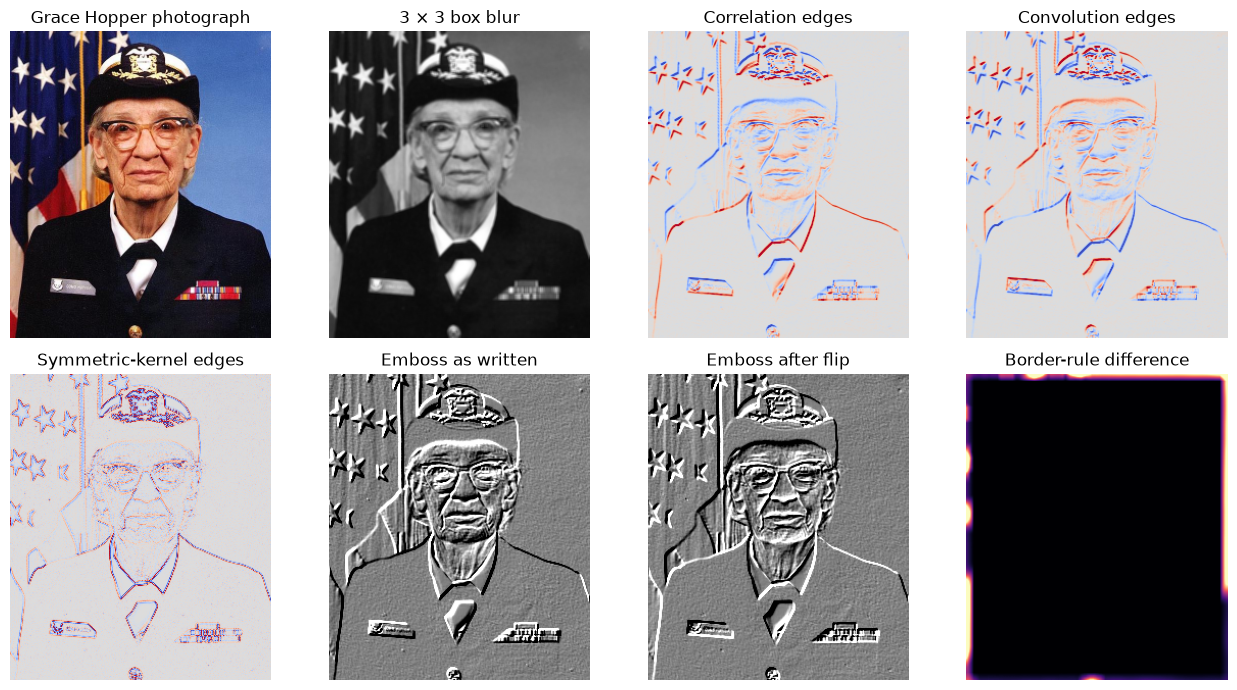

Saved: C:\Users\Adity\Downloads\Official-Website-portfolio\results\lesson-01-5\07-photo-filter-summary.png
Verified image files: 7
Saved: C:\Users\Adity\Downloads\Official-Website-portfolio\results\lesson-01-5\measurements.txt


In [26]:
if not (CHECKS_PASSED and EMBOSS_CHECK_PASSED):
    raise RuntimeError("Checks must pass before writing outputs")

figure, axes = plt.subplots(2, 4, figsize=(13, 7))
summary_panels = (
    (photo_rgb, "Grace Hopper photograph", "rgb"),
    (box_blurred, "3 × 3 box blur", "gray"),
    (correlation_image, "Correlation edges", "signed"),
    (convolution_image, "Convolution edges", "signed"),
    (
        symmetric_correlation_image,
        "Symmetric-kernel edges",
        "signed",
    ),
    (
        emboss_correlation_image,
        "Emboss as written",
        "gray",
    ),
    (
        emboss_convolution_image,
        "Emboss after flip",
        "gray",
    ),
    (
        border_difference_image,
        "Border-rule difference",
        "change",
    ),
)
for axis, (image, title, display) in zip(axes.flat, summary_panels):
    plot_image(axis, image, title, display=display)
summary_file = save_figure(figure, "07-photo-filter-summary.png")

image_files = (
    RESULTS_DIR / "01-box-blur.png",
    RESULTS_DIR / "02-correlation-edges.png",
    RESULTS_DIR / "03-convolution-edges.png",
    RESULTS_DIR / "04-symmetric-edges.png",
    RESULTS_DIR / "05-border-effects.png",
    RESULTS_DIR / "06-emboss-directions.png",
    summary_file,
)
for image_file in image_files:
    if not image_file.is_file() or image_file.stat().st_size == 0:
        raise RuntimeError(f"Missing output image: {image_file}")

measurements_file = RESULTS_DIR / "measurements.txt"
measurements_file.write_text(
    f"branch={BRANCH}\n"
    f"sample_photo={PHOTO_PATH.name}\n"
    f"numpy_version={np.__version__}\n"
    f"opencv_version={cv2.__version__}\n"
    f"correlation={correlation_result:.6f}\n"
    f"convolution={convolution_result:.6f}\n"
    f"symmetric_difference={symmetric_difference:.6f}\n"
    f"constant_corner_response={constant_response:.6f}\n"
    f"reflect_corner_response={reflect_response:.6f}\n"
    f"emboss_kernel_sum={float(emboss_kernel.sum()):.6f}\n"
    f"emboss_flip_is_negative={np.array_equal(emboss_flipped, -emboss_kernel)}\n"
    f"image_count={len(image_files)}\n",
    encoding="utf-8",
)

print("Verified image files:", len(image_files))
print("Saved:", measurements_file)

## Sources

- OpenCV 5.0, Image Filtering:
  <https://docs.opencv.org/5.0/main_modules/imgproc_filter.html>
- NumPy, `numpy.pad`:
  <https://numpy.org/doc/stable/reference/generated/numpy.pad.html>
- Matplotlib, `matplotlib.cbook.get_sample_data`:
  <https://matplotlib.org/stable/api/cbook_api.html#matplotlib.cbook.get_sample_data>

Checked in the local `ac-cv` environment on 2026-07-29.